# Theoretical relation analysis
The theoretical relation between water and sediment discharges is:
$ y [t/h]= 0,0093 x^2 + 4,2903 x - 202,1$

x in $m^3/s$
following a Jaggi relation.

In [1]:
#  imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
# import datasets

multi_scan=pd.read_csv("Multi_flood.dat", sep='\t', header=1, 
                       usecols=[0,1,9,16])
multi_scan.columns=['Time[s]', 'Q [m3/s]','Qsed_in_tot[m3/s]', 'Qsed_out_tot[m3/s]']
multi_scan['Qsed_out_tot[m3/s]']=abs(multi_scan['Qsed_out_tot[m3/s]']) # make sure sediment discharge is positive
multi_scan['Qsed_in_tot[m3/s]']=abs(multi_scan['Qsed_in_tot[m3/s]'])
print(multi_scan.head())

single_scan=pd.read_csv(r"C:\Users\marga\Documents\EPFL\Cours\S3\Dranse\BASEMENT_model\Dranse_sediment\Basement-v4\Morphodynamic_single-v4\Dranse_bnd_combined_th.dat", sep='\t', header=1,
                        usecols=[0,1,2,4])
single_scan.columns=['Time[s]', 'Q [m3/s]','Qsed_in tot [m3/s]', 'Qsed_out[m3/s]']

single_scan['Qsed_out[m3/s]']=abs(single_scan['Qsed_out[m3/s]']) # make sure sediment discharge is positive

# Theoretical
# relation

def jaggi_relation(x):
    return 0.0093*x**2 + 4.2903*x - 202.1
# x in m3/s
# y in t/h

rho_sediment=2650 #kg/m3

def sediment_discharge(Q_sed):
    """Convert sediment discharge from t/h to m3/s"""
    Q_sed_m3s = Q_sed / rho_sediment / 3600
    return Q_sed_m3s



   Time[s]   Q [m3/s]  Qsed_in_tot[m3/s]  Qsed_out_tot[m3/s]
0   115000  18.963744           0.000015            0.015833
1   120000  22.378423           0.001727            0.017688
2   125000  20.080932           0.000037            0.018539
3   130000  23.952836           0.000080            0.020245
4   135000  34.448461           0.000355            0.024561


In [6]:
# theoretical sediment discharge from scan period discharge
multi_scan['Q_sed_theoretical_tph'] = jaggi_relation(multi_scan['Q [m3/s]'])
multi_scan['Q_sed_theoretical_m3s'] = sediment_discharge(multi_scan['Q_sed_theoretical_tph']).clip(lower=0) # clip negative values to 0
print(multi_scan.head())


   Time[s]   Q [m3/s]  Qsed_in_tot[m3/s]  Qsed_out_tot[m3/s]  \
0   115000  18.963744           0.000015            0.015833   
1   120000  22.378423           0.001727            0.017688   
2   125000  20.080932           0.000037            0.018539   
3   130000  23.952836           0.000080            0.020245   
4   135000  34.448461           0.000355            0.024561   

   Q_sed_theoretical_tph  Q_sed_theoretical_m3s  
0            -117.395350                    0.0  
1            -101.432469                    0.0  
2            -112.196610                    0.0  
3             -93.999381                    0.0  
4             -43.269491                    0.0  


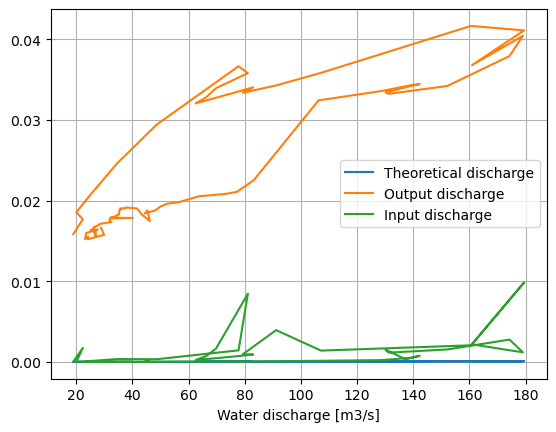

In [13]:
# plot sed discharges
plt.grid()
plt.plot(multi_scan['Q [m3/s]'],multi_scan['Q_sed_theoretical_m3s'], label='Theoretical discharge')
plt.plot(multi_scan['Q [m3/s]'],multi_scan['Qsed_out_tot[m3/s]'], label='Output discharge')
plt.plot(multi_scan['Q [m3/s]'],multi_scan['Qsed_in_tot[m3/s]'], label='Input discharge')
plt.xlabel('Water discharge [m3/s]')
plt.legend()

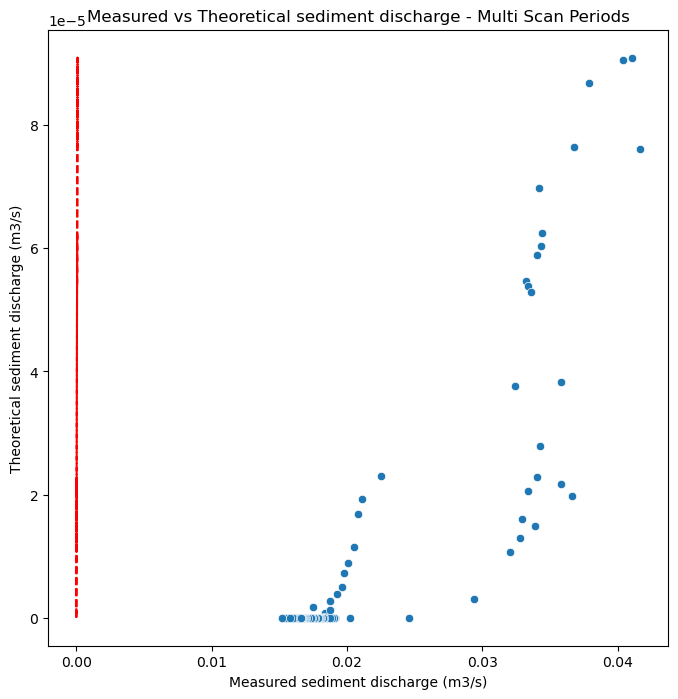

In [8]:
# QQ plots

ax, fig = plt.subplots(figsize=(8,8))
sns.scatterplot(data=multi_scan, x='Qsed_out_tot[m3/s]', y='Q_sed_theoretical_m3s')

plt.plot(multi_scan['Q_sed_theoretical_m3s'],multi_scan['Q_sed_theoretical_m3s'], color='red', linestyle='--')
plt.xlabel('Measured sediment discharge (m3/s)')
plt.ylabel('Theoretical sediment discharge (m3/s)')
plt.title('Measured vs Theoretical sediment discharge - Multi Scan Periods')
plt.show()


In [40]:
# total sediment volume during multi scan periods
print( multi_scan['Qsed_out_tot[m3/s]'])
total_sediment_volume_m3 = multi_scan['Qsed_out_tot[m3/s]'][81]
print(f'Total sediment volume during study period: {total_sediment_volume_m3:.2f} m3')

theoretical_total_sediment_volume_m3 = (multi_scan['Q_sed_theoretical_m3s']*5000).sum()
print(f'Theoretical total sediment volume during study period: {theoretical_total_sediment_volume_m3:.2f} m3')

0     0.015833
1     0.017688
2     0.018539
3     0.020245
4     0.024561
        ...   
78    0.015203
79    0.015748
80    0.016555
81    0.016586
82         NaN
Name: Qsed_out_tot[m3/s], Length: 83, dtype: float64
Total sediment volume during study period: 0.02 m3
Theoretical total sediment volume during study period: 5.91 m3


## Sediment sizes analysis
Using flood event of 2000


In [35]:

#initial sediment distribution

Sizes_classes_mm = [7, 20, 33, 46, 59] # in mm
sediment_init_percentage= [36.4, 20.6, 11.8, 16.0, 15.2] # in %

# import matrix of sediment percentages for 5 classes for each timestep
X_out=pd.read_csv("Multi_flood.dat", sep='\t', header=0, usecols=[10,11,12,13,14])
X_out


,bnd_outflow[Qsed d=7 mm [m3/s]],bnd_outflow[Qsed d=20 mm [m3/s]],bnd_outflow[Qsed d=33 mm [m3/s]],bnd_outflow[Qsed d=46 mm [m3/s]],bnd_outflow[Qsed d=59 mm [m3/s]]
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,5.607097e-06,3.141262e-06,1.799364e-06,2.439815e-06,2.317824e-06
2,8.161909e-04,3.326655e-04,1.589651e-04,2.150890e-04,2.043346e-04
3,2.011987e-05,6.529437e-06,2.746472e-06,3.702974e-06,3.517826e-06
4,5.027123e-05,1.279211e-05,4.800245e-06,6.218855e-06,5.905300e-06
...,...,...,...,...,...
79,4.098599e-11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
80,6.832317e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
81,2.583040e-11,4.038160e-12,6.311198e-13,5.521482e-13,2.328697e-13
82,3.793335e-10,5.930259e-11,9.268340e-12,8.108599e-12,3.419819e-12


In [49]:
# average sediment percentage over the flood event
average_sediment_percentage = X_out.sum(axis=0) /X_out.sum(axis=0).sum()*100
average_sediment_percentage

bnd_outflow[Qsed d=7 mm [m3/s]]      57.612813
bnd_outflow[Qsed d=20 mm [m3/s]]     26.654231
bnd_outflow[Qsed d=33 mm [m3/s]]      8.566943
bnd_outflow[Qsed d=46 mm [m3/s]]      4.676159
bnd_outflow[Qsed d=59 mm [m3/s]]      2.489853
dtype: float64

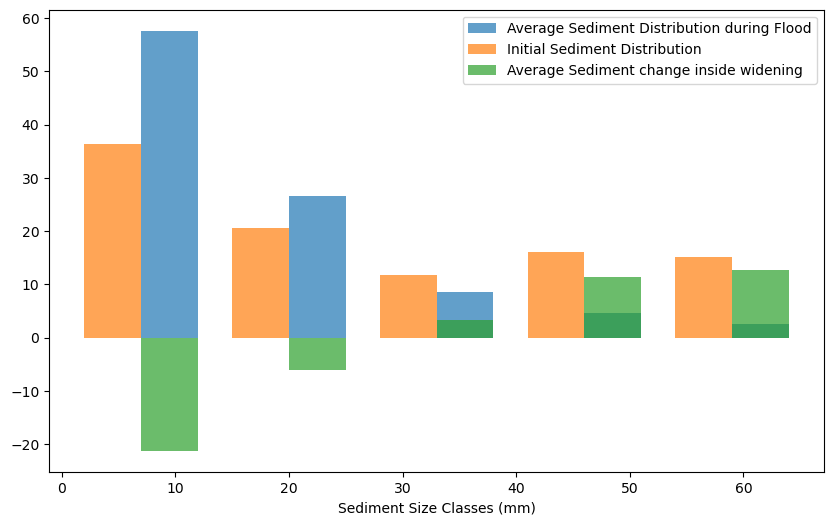

In [52]:
# plot histogram of average and initial sediment distributions
fig, ax = plt.subplots(figsize=(10,6))
width = 5
ax.bar(np.array(Sizes_classes_mm)+width/2, average_sediment_percentage, width=width, label='Average Sediment Distribution during Flood', alpha=0.7)
ax.bar(np.array(Sizes_classes_mm)-width/2, sediment_init_percentage, width=width, label='Initial Sediment Distribution', alpha=0.7)
ax.bar(np.array(Sizes_classes_mm)+width/2, sediment_init_percentage-average_sediment_percentage, width=width, label='Average Sediment change inside widening', alpha=0.7)

ax.set_xlabel('Sediment Size Classes (mm)')
plt.legend()